In [1]:
import pandas as pd

df=pd.read_csv('./Wholesale customers data.csv')  
df.head()



,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [3]:
df.isna().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [6]:
behavior_df = df[['Fresh', 'Milk', 'Grocery', 'Frozen', 
                  'Detergents_Paper', 'Delicassen']]


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(behavior_df)


In [8]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)


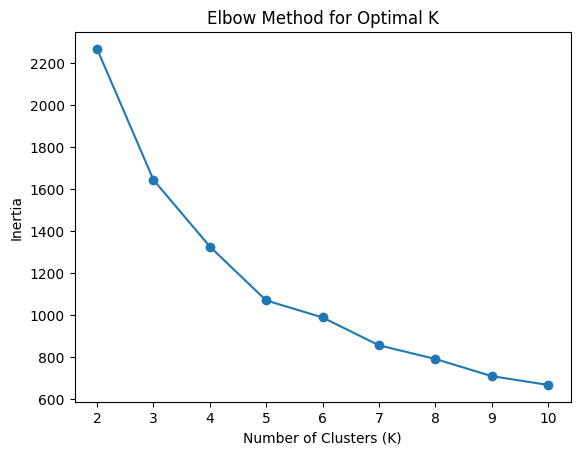

In [9]:
import matplotlib.pyplot as plt

plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


In [17]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters


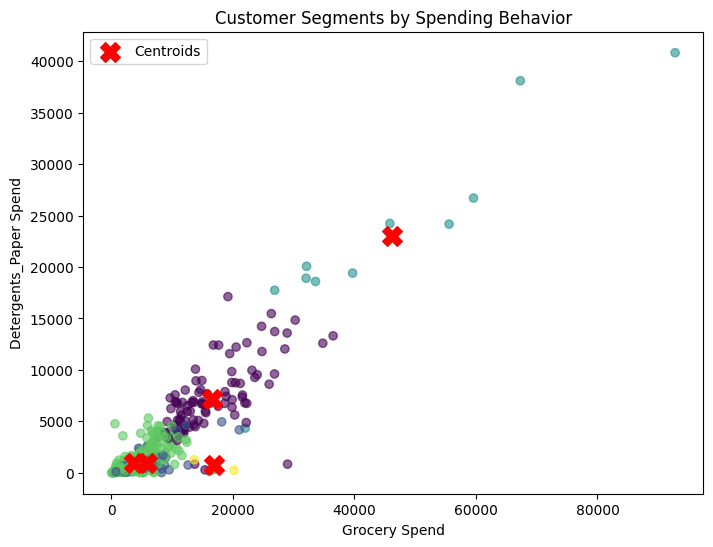

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(df['Grocery'], df['Detergents_Paper'],
            c=df['Cluster'], cmap='viridis', alpha=0.6)

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:,2], centers[:,4],
            c='red', s=200, marker='X', label='Centroids')

plt.xlabel('Grocery Spend')
plt.ylabel('Detergents_Paper Spend')
plt.title('Customer Segments by Spending Behavior')
plt.legend()
plt.show()


In [15]:
cluster_profile = df.groupby('Cluster')[[
    'Fresh','Milk','Grocery','Frozen',
    'Detergents_Paper','Delicassen'
]].mean()


In [16]:
kmeans_alt = KMeans(n_clusters=4, random_state=99)
df['Cluster_alt'] = kmeans_alt.fit_predict(scaled_data)
